In [1]:
import sys
import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Path setup
BASE_DIR = os.path.abspath(os.getcwd())
if BASE_DIR not in sys.path: sys.path.insert(0, BASE_DIR)
sys.path.insert(0, os.path.join(BASE_DIR, "src"))
os.makedirs(os.path.join(BASE_DIR, "assets", "figs"), exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


--- KIỂM TRA CHẤT LƯỢNG DỮ LIỆU ---
Tổng số bản ghi: 5000
Số giá trị Null trong Category: 0
Số bản ghi trùng lặp (Title): 2131


C:\Users\dhp01\AppData\Local\Temp\ipykernel_21000\226897066.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=cat_counts.index, x=cat_counts.values, ax=axes[0], palette="viridis")


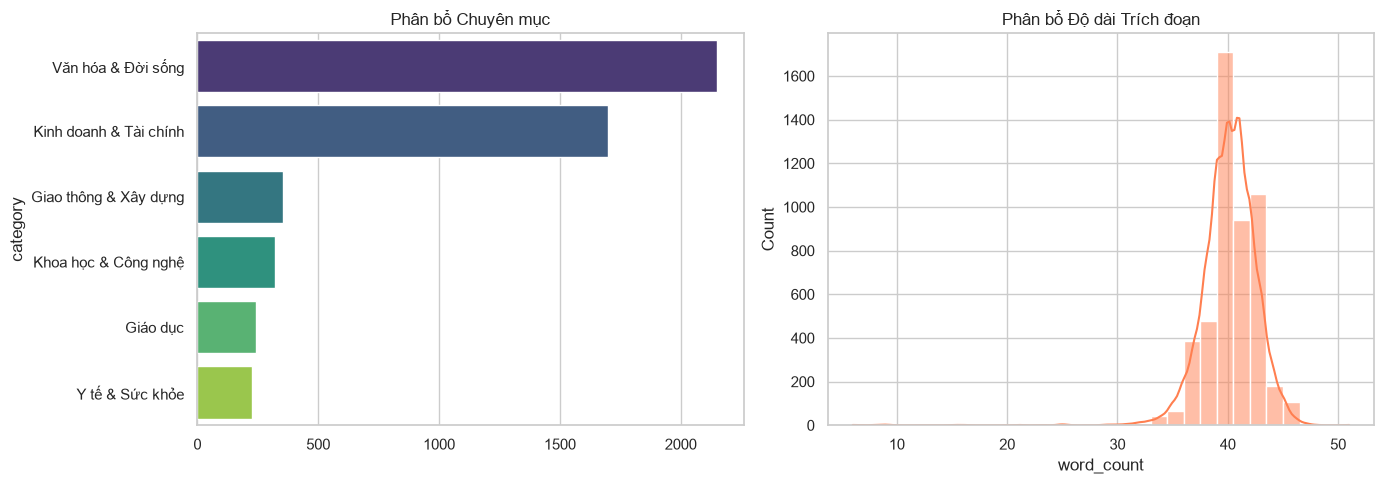

In [2]:
# Nạp Metadata
meta_path = os.path.join(BASE_DIR, "data", "processed", "search_index_metadata.json")
with open(meta_path, "r", encoding="utf-8") as f:
    metadata = json.load(f)

df_meta = pd.DataFrame(metadata)
df_meta['word_count'] = df_meta['preview'].apply(lambda x: len(str(x).split()))

print("--- KIỂM TRA CHẤT LƯỢNG DỮ LIỆU ---")
print(f"Tổng số bản ghi: {len(df_meta)}")
print(f"Số giá trị Null trong Category: {df_meta['category'].isnull().sum()}")
print(f"Số bản ghi trùng lặp (Title): {df_meta.duplicated(subset=['title']).sum()}")

# Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cat_counts = df_meta['category'].value_counts()
sns.barplot(y=cat_counts.index, x=cat_counts.values, ax=axes[0], palette="viridis")
axes[0].set_title("Phân bổ Chuyên mục")

sns.histplot(df_meta['word_count'], bins=30, kde=True, ax=axes[1], color="coral")
axes[1].set_title("Phân bổ Độ dài Trích đoạn")

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "assets", "figs", "eda_dist.png"), dpi=300)
plt.show()


--- PHÂN TÍCH VECTOR ---
Shape: (5000, 384)
Norm L2 trung bình: 1.0000


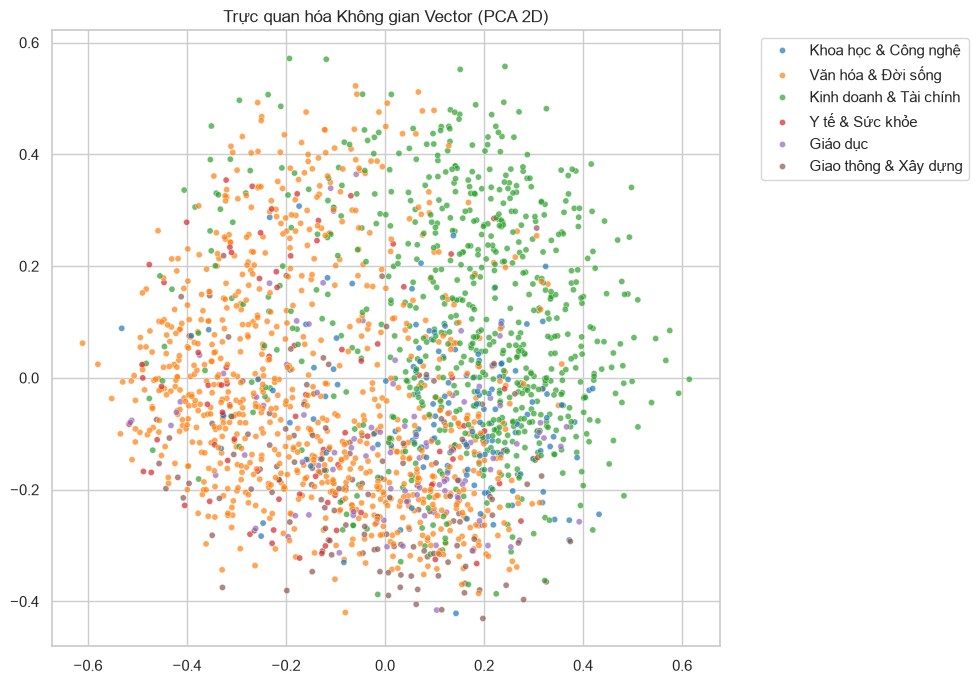

In [3]:
# Nạp Vector & Phân tích Không gian Vector
npz_path = os.path.join(BASE_DIR, "data", "processed", "search_index_cache.npz")
data = np.load(npz_path)
vectors = data["vectors"].astype(np.float32)

print("--- PHÂN TÍCH VECTOR ---")
print(f"Shape: {vectors.shape}")
print(f"Norm L2 trung bình: {np.mean(np.linalg.norm(vectors, axis=1)):.4f}")

# Dùng PCA giảm chiều để trực quan hóa cụm vector
pca = PCA(n_components=2)
# Lấy mẫu 2000 vector để vẽ cho nhẹ
sample_idx = np.random.choice(vectors.shape[0], 2000, replace=False)
vecs_2d = pca.fit_transform(vectors[sample_idx])
categories_sample = df_meta.iloc[sample_idx]['category'].values

plt.figure(figsize=(10, 7))
sns.scatterplot(x=vecs_2d[:, 0], y=vecs_2d[:, 1], hue=categories_sample, palette="tab10", s=20, alpha=0.7)
plt.title("Trực quan hóa Không gian Vector (PCA 2D)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "assets", "figs", "pca_clusters.png"), dpi=300)
plt.show()


In [4]:
from ann_index.hnsw import StandardHNSWIndex
from ann_index.two_tier_hnsw import TwoTierQuantizedHNSW

print("Khởi tạo Standard HNSW...")
std_index = StandardHNSWIndex(m=16, ef_construction=200)
std_index.build(vectors)

print("Khởi tạo Two-Tier Quantized HNSW...")
two_tier_index = TwoTierQuantizedHNSW(m=16, ef_search=40)
two_tier_index.build(vectors)


Khởi tạo Standard HNSW...


Khởi tạo Two-Tier Quantized HNSW...


In [5]:
def run_retrieval_experiment(num_queries=200, top_k=10):
    np.random.seed(42)
    query_indices = np.random.choice(vectors.shape[0], num_queries, replace=False)
    query_vectors = vectors[query_indices]
    
    results = []
    
    for i, q in enumerate(query_vectors):
        q_2d = np.expand_dims(q, axis=0)
        
        t0 = time.perf_counter()
        std_idx, std_dist = std_index.search(q_2d, top_k=top_k)
        t_std = (time.perf_counter() - t0) * 1000
        
        t1 = time.perf_counter()
        tt_idx, tt_dist = two_tier_index.search(q_2d, top_k=top_k)
        t_tt = (time.perf_counter() - t1) * 1000
        
        std_results = list(std_idx[0])
        tt_results = list(tt_idx[0])
        
        # Calculate Recalls
        intersection = len(set(std_results) & set(tt_results))
        recall_at_10 = intersection / top_k
        top1_match = 1 if std_results[0] == tt_results[0] else 0
        
        results.append({
            "std_latency_ms": t_std,
            "two_tier_latency_ms": t_tt,
            "std_top1_dist": std_dist[0][0],
            "two_tier_top1_dist": tt_dist[0][0],
            "top1_match": top1_match,
            "recall_at_10": recall_at_10
        })
        
    return pd.DataFrame(results)

df_exp = run_retrieval_experiment(num_queries=500, top_k=10)
print(f"Recall@1 Trung bình: {df_exp['top1_match'].mean():.4f}")
print(f"Recall@10 Trung bình: {df_exp['recall_at_10'].mean():.4f}")


Recall@1 Trung bình: 0.9260
Recall@10 Trung bình: 0.9278


C:\Users\dhp01\AppData\Local\Temp\ipykernel_21000\3665756231.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Algorithm', y='Latency (ms)', data=lat_data, ax=axes[0], palette="Set2")
C:\Users\dhp01\AppData\Local\Temp\ipykernel_21000\3665756231.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Standard HNSW', 'Two-Tier SQ8'], y=[std_qps, tt_qps], ax=axes[1], palette="Set2")


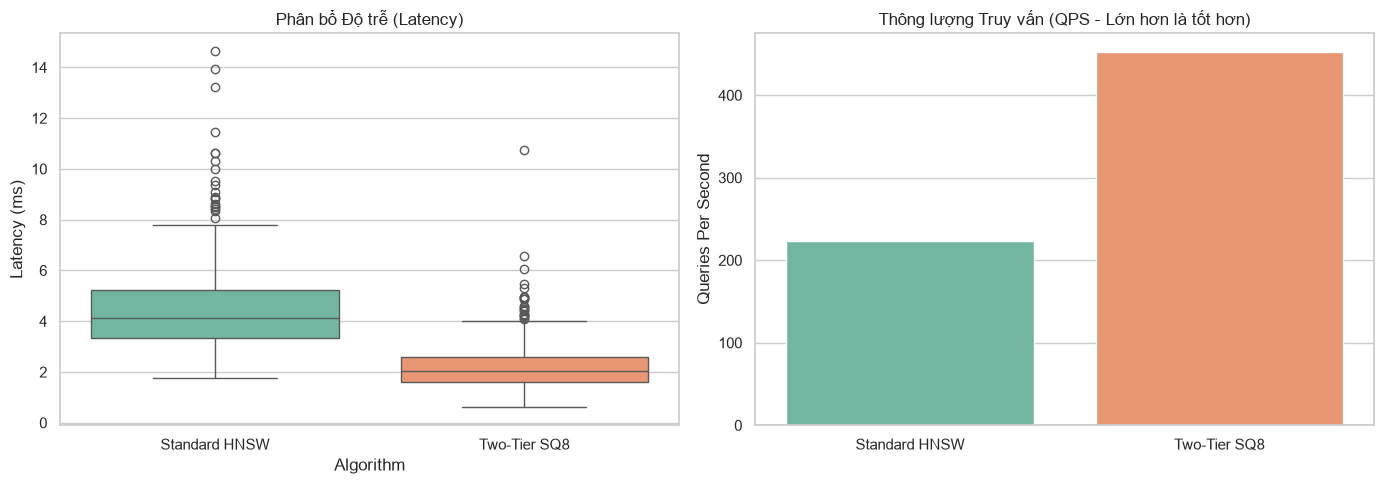

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Latency
lat_data = pd.melt(df_exp, value_vars=['std_latency_ms', 'two_tier_latency_ms'], var_name='Algorithm', value_name='Latency (ms)')
lat_data['Algorithm'] = lat_data['Algorithm'].map({'std_latency_ms': 'Standard HNSW', 'two_tier_latency_ms': 'Two-Tier SQ8'})
sns.boxplot(x='Algorithm', y='Latency (ms)', data=lat_data, ax=axes[0], palette="Set2")
axes[0].set_title("Phân bổ Độ trễ (Latency)")

# 2. QPS
std_qps = 1000 / df_exp['std_latency_ms'].mean()
tt_qps = 1000 / df_exp['two_tier_latency_ms'].mean()
sns.barplot(x=['Standard HNSW', 'Two-Tier SQ8'], y=[std_qps, tt_qps], ax=axes[1], palette="Set2")
axes[1].set_title("Thông lượng Truy vấn (QPS - Lớn hơn là tốt hơn)")
axes[1].set_ylabel("Queries Per Second")

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "assets", "figs", "perf_latency_qps.png"), dpi=300)
plt.show()


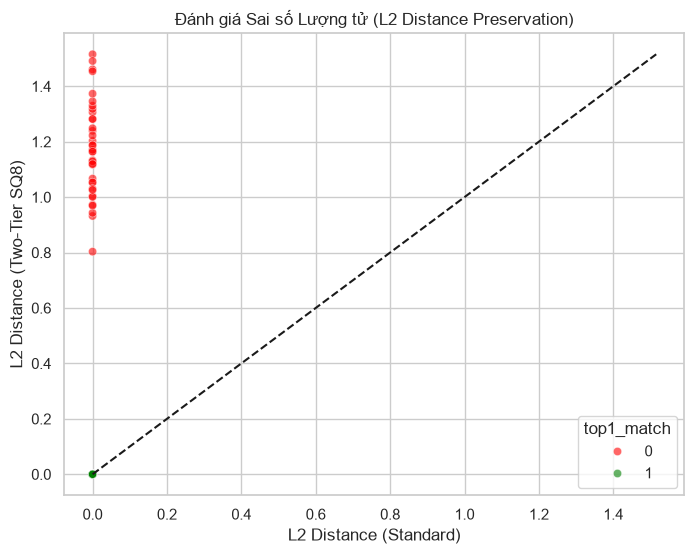

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='std_top1_dist', y='two_tier_top1_dist', hue='top1_match', data=df_exp, palette={0: "red", 1: "green"}, alpha=0.6)
max_val = max(df_exp['std_top1_dist'].max(), df_exp['two_tier_top1_dist'].max())
plt.plot([0, max_val], [0, max_val], 'k--')
plt.title("Đánh giá Sai số Lượng tử (L2 Distance Preservation)")
plt.xlabel("L2 Distance (Standard)")
plt.ylabel("L2 Distance (Two-Tier SQ8)")
plt.savefig(os.path.join(BASE_DIR, "assets", "figs", "l2_scatter.png"), dpi=300)
plt.show()
